# APEX — obstacle detection + avoidance test bench

**Standalone.** This notebook does not import or modify any of the flight code
(`pi5_main.py`, `stream_server.py`, `webcam.py`, the IK engine, the serial
protocol). It only reads from the webcam. Nothing here talks to the Picos or
moves a motor — the "avoidance" step just prints the steering angle it *would*
publish to `/apex/navigation/cmd_dir`.

Run order:
1. install deps
2. download the pretrained depth model (Depth-Anything-V2-Small, ONNX)
3. build the pipeline: frame → depth map → obstacle costmap → steering decision
4. tests: sample images, single webcam frame, live loop, FPS benchmark, synthetic sanity check

The dog crawls one leg at a time (~15 cm/s), so 1–3 FPS on the Pi 5 CPU is
plenty — no AI HAT / Coral needed.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "onnxruntime", "opencv-python", "numpy", "matplotlib"], check=False)
print("deps ready")

deps ready


In [2]:
import os, time, pathlib, urllib.request, sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Import the SAME module the robot runs, so anything tuned here is what
# flies. Nothing in this notebook re-implements the pipeline any more --
# an earlier version did, and the two silently drifted apart.
HERE = pathlib.Path.cwd()
sys.path.insert(0, str(HERE.parent))          # Code/Pi5
import vision_obstacle as V

MODEL_DIR = HERE / "models";      MODEL_DIR.mkdir(exist_ok=True)
IMG_DIR   = HERE / "test_images"; IMG_DIR.mkdir(exist_ok=True)

# repo: https://huggingface.co/onnx-community/depth-anything-v2-small
MODEL_FP32 = "https://huggingface.co/onnx-community/depth-anything-v2-small/resolve/main/onnx/model.onnx"
MODEL_INT8 = "https://huggingface.co/onnx-community/depth-anything-v2-small/resolve/main/onnx/model_quantized.onnx"

USE_INT8   = False
MODEL_URL  = MODEL_INT8 if USE_INT8 else MODEL_FP32
MODEL_PATH = MODEL_DIR / ("depth_anything_v2_s_int8.onnx" if USE_INT8 else "depth_anything_v2_s.onnx")

# same camera path the real robot uses; falls back to index 0 if absent
CAM_DEVICE = "/dev/v4l/by-id/usb-Sonix_Technology_Co.__Ltd._USB_Camera_SN0001-video-index0"

print("using vision_obstacle from:", V.__file__)
print(f"ROI {V.ROI_TOP}-{V.ROI_BOTTOM}  bins {V.N_BINS}  "
      f"margin {V.OBSTACLE_MARGIN}  block {V.BLOCK_FRAC}")

using vision_obstacle from: c:\Users\david\Desktop\APEX\Code\Pi5\vision_obstacle.py
ROI 0.45-0.95  bins 9  margin 0.12  block 0.25


In [3]:
def download(url, dest, force=False):
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 0 and not force:
        print(f"cached  {dest.name}  ({dest.stat().st_size/1e6:.1f} MB)")
        return dest
    print(f"GET  {url}")
    req = urllib.request.Request(url, headers={"User-Agent": "apex-vision-test/1.0"})
    with urllib.request.urlopen(req) as r, open(dest, "wb") as f:
        total = int(r.headers.get("Content-Length", 0)); got = 0
        while True:
            chunk = r.read(1 << 20)
            if not chunk:
                break
            f.write(chunk); got += len(chunk)
            if total:
                print(f"\r  {got/1e6:6.1f} / {total/1e6:.1f} MB", end="")
    print(f"\r  saved {dest.name}  ({dest.stat().st_size/1e6:.1f} MB)      ")
    return dest

download(MODEL_URL, MODEL_PATH)

cached  depth_anything_v2_s.onnx  (99.1 MB)


WindowsPath('c:/Users/david/Desktop/APEX/Code/Pi5/vision_test/models/depth_anything_v2_s.onnx')

## Pipeline

Everything below comes from `Code/Pi5/vision_obstacle.py` — the module the
robot actually runs. Tune the constants there and re-run these cells.

**depth** — Depth-Anything emits *inverse* depth (bright = near), 0..1.

**costmap** — this is the part that is easy to get wrong. On flat ground the
distance to the ground at image row `r` goes as `1/(r - horizon)`, so inverse
depth ramps smoothly from far at the top of the frame to near at the bottom.
An absolute threshold therefore flags **the ground itself**: bare open ground
scored 0.42 in every bin against a 0.25 block threshold — "fully blocked"
with nothing in front of the robot at all.

So a pixel counts as an obstacle when it reads nearer than the ground does
**at its own row** (`OBSTACLE_MARGIN` past that row's `GROUND_REF_PCT`
percentile). An upright object occupies rows that would otherwise show ground
far away, so it stands out sharply. A uniform slope shifts a whole row
together and is *not* flagged, which is what you want on terrain.

In [4]:
depth_model = V.DepthEstimator(MODEL_PATH, input_size=V.INPUT_SIZE)
print("input ", depth_model.input_name, depth_model.session.get_inputs()[0].shape)
print("output", depth_model.output_name, depth_model.session.get_outputs()[0].shape)

input  pixel_values ['batch_size', 3, 'height', 'width']
output predicted_depth ['floor(1.0*batch_size)', '14*floor(height/14)', '14*floor(width/14)']


In [5]:
planner = V.AvoidancePlanner()

def analyze(bgr, desired_deg=0.0, reset=True):
    """frame -> (depth, costmap, decision), all through the production code."""
    if reset:
        planner.reset()       # per-image, so a still cannot inherit a detour
    t0 = time.time()
    depth = depth_model.infer(bgr)
    cost = V.costmap_from_depth(depth)
    dec = planner.update(cost, desired_deg)
    dec.ms = (time.time() - t0) * 1000.0
    return depth, cost, dec

In [6]:
def show(bgr, depth, cost, dec):
    h, w = bgr.shape[:2]
    ov = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
    y0, y1 = int(h * V.ROI_TOP), int(h * V.ROI_BOTTOM)
    for i in range(len(cost)):
        x0, x1 = int(i * w / len(cost)), int((i + 1) * w / len(cost))
        col = (255, 0, 0) if cost[i] >= V.BLOCK_FRAC else (0, 200, 0)
        cv2.rectangle(ov, (x0, y0), (x1, y1), col, 2)

    # What the costmap actually thresholds: nearer than this row's ground.
    roi = depth[y0:y1, :]
    ref = np.percentile(roi, V.GROUND_REF_PCT, axis=1, keepdims=True)
    mask = np.zeros_like(depth, bool)
    mask[y0:y1, :] = (roi - ref) > V.OBSTACLE_MARGIN

    fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))
    ax[0].imshow(ov);                  ax[0].set_title("frame + ROI bins")
    ax[1].imshow(depth, cmap="turbo"); ax[1].set_title("depth (bright = near)")
    ax[2].imshow(mask, cmap="gray")
    ax[2].set_title("nearer than its row's ground")
    for a in ax[:3]:
        a.axis("off")
    ax[3].bar(range(len(cost)), cost,
              color=["red" if c >= V.BLOCK_FRAC else "green" for c in cost])
    ax[3].axhline(V.BLOCK_FRAC, ls="--", c="k")
    ax[3].set_ylim(0, 1); ax[3].set_xlabel("bin (L->R)")
    ax[3].set_title(f"{dec.state}  steer {dec.steer_deg:+.0f}  "
                    f"stride x{dec.stride_scale:.2f}  ({dec.ms:.0f} ms)\n{dec.reason}")
    plt.tight_layout(); plt.show()

## Test 1 — real ground-robot imagery

These are **not** scenic photos. Every one is shot from a ground robot with
the camera low and pointed straight ahead, so the ground plane fills the
lower frame the way it does on APEX — which is the whole premise the costmap
rests on. A handheld landscape shot has the horizon in the middle and tells
you nothing about whether this works.

| image | source | what it exercises |
|---|---|---|
| `corridor_bottle` | GMRPD | indoor corridor, walls both sides, small bottle on the floor |
| `paving_box` | GMRPD | outdoor paving, low cardboard box, drain grate, hedge |
| `trail_narrow` | Freiburg Forest | forest trail, earth bank close on the left |
| `trail_pinch` | Freiburg Forest | trail pinching between bushes, straight into the sun |
| `trail_fork` | Freiburg Forest | trail forks, vegetation splitting the two branches |
| `trail_twotrack` | Freiburg Forest | two-track path, grass and mud texture underfoot |
| `trail_dusk` | Freiburg Forest | flat overcast light, dark bank filling the left |
| `trail_open` | Freiburg Forest | open grass, conifers in the middle distance |

Between them they cover: clear ground, obstacle on one side, obstacles on
both sides, a gap too narrow to fit, a fork to choose between, ground texture
that must **not** trip, poor light, and distant objects that must **not**
block.

*Provenance:* GMRPD is the Ground Mobile Robot Perception Dataset
([hlwang1124/GMRPD](https://github.com/hlwang1124/GMRPD), IEEE RA-L / T-CYB).
The trail images are from the Freiburg Forest / DeepScene dataset as
redistributed in
[dusty-nv/jetson-inference](https://github.com/dusty-nv/jetson-inference).

In [7]:
GMRPD = "https://raw.githubusercontent.com/hlwang1124/GMRPD/master/samples/"
JETSON = "https://raw.githubusercontent.com/dusty-nv/jetson-inference/master/data/images/"

# name -> (url, what it tests, verdict recorded from a real run)
TEST_IMAGES = {
    "corridor_bottle": (GMRPD  + "sample1_rgb.png",
        "walls both sides, bottle on the floor", "AVOIDING"),
    "paving_box":      (GMRPD  + "sample2_rgb.png",
        "low box on textured paving, hedge right", "CLEAR"),
    "trail_narrow":    (JETSON + "trail_0.jpg",
        "earth bank close on the left", "CLEAR"),
    "trail_pinch":     (JETSON + "trail_2.jpg",
        "gap pinches below body width; into the sun", "BLOCKED"),
    "trail_fork":      (JETSON + "trail_3.jpg",
        "fork -- vegetation splits the path", "CLEAR"),
    "trail_twotrack":  (JETSON + "trail_4.jpg",
        "grass/mud texture must not trip", "CLEAR"),
    "trail_dusk":      (JETSON + "trail_6.jpg",
        "flat light, dark bank fills the left", "AVOIDING"),
    "trail_open":      (JETSON + "trail_8.jpg",
        "distant conifers must not block", "CLEAR"),
}

for name, (url, _, _) in TEST_IMAGES.items():
    dest = IMG_DIR / (name + pathlib.Path(url).suffix)
    try:
        download(url, dest)
    except Exception as e:
        print(f"skip {name}: {e}")

cached  corridor_bottle.png  (0.9 MB)
cached  paving_box.png  (1.4 MB)
cached  trail_narrow.jpg  (0.1 MB)
cached  trail_pinch.jpg  (0.1 MB)
cached  trail_fork.jpg  (0.1 MB)
cached  trail_twotrack.jpg  (0.1 MB)
cached  trail_dusk.jpg  (0.0 MB)
cached  trail_open.jpg  (0.1 MB)


In [8]:
import pathlib

print(f"{'image':17s} {'bins':11s} {'verdict':9s} steer stride  vs recorded")
print("-" * 78)

results = {}
for name, (url, what, expected) in TEST_IMAGES.items():
    path = IMG_DIR / (name + pathlib.Path(url).suffix)
    bgr = cv2.imread(str(path))
    if bgr is None:
        print(f"{name:17s} (not downloaded)")
        continue
    depth, cost, dec = analyze(bgr)
    results[name] = (bgr, depth, cost, dec)
    bars = "".join("#" if c >= V.BLOCK_FRAC else "." for c in cost)
    flag = "same" if dec.state == expected else f"was {expected}"
    print(f"{name:17s} [{bars}] {dec.state:9s} {dec.steer_deg:+5.0f} {dec.stride_scale:5.2f}  {flag}")

print()
print("The recorded column is a baseline from one real run, not ground truth --\n"
      "if you retune ROI_* or OBSTACLE_MARGIN these are SUPPOSED to move. It is\n"
      "there so an unintended change is visible.")

image             bins        verdict   steer stride  vs recorded
------------------------------------------------------------------------------
corridor_bottle   [#.....###] AVOIDING    -22  0.60  same
paving_box        [........#] CLEAR        +0  1.00  same
trail_narrow      [##.......] CLEAR        +0  1.00  same
trail_pinch       [###....##] BLOCKED      +0  0.00  same
trail_fork        [##.......] CLEAR        +0  1.00  same
trail_twotrack    [#........] CLEAR        +0  1.00  same
trail_dusk        [#####....] AVOIDING    +35  0.60  same
trail_open        [.........] CLEAR        +0  1.00  same

The recorded column is a baseline from one real run, not ground truth --
if you retune ROI_* or OBSTACLE_MARGIN these are SUPPOSED to move. It is
there so an unintended change is visible.


=== corridor_bottle: walls both sides, bottle on the floor


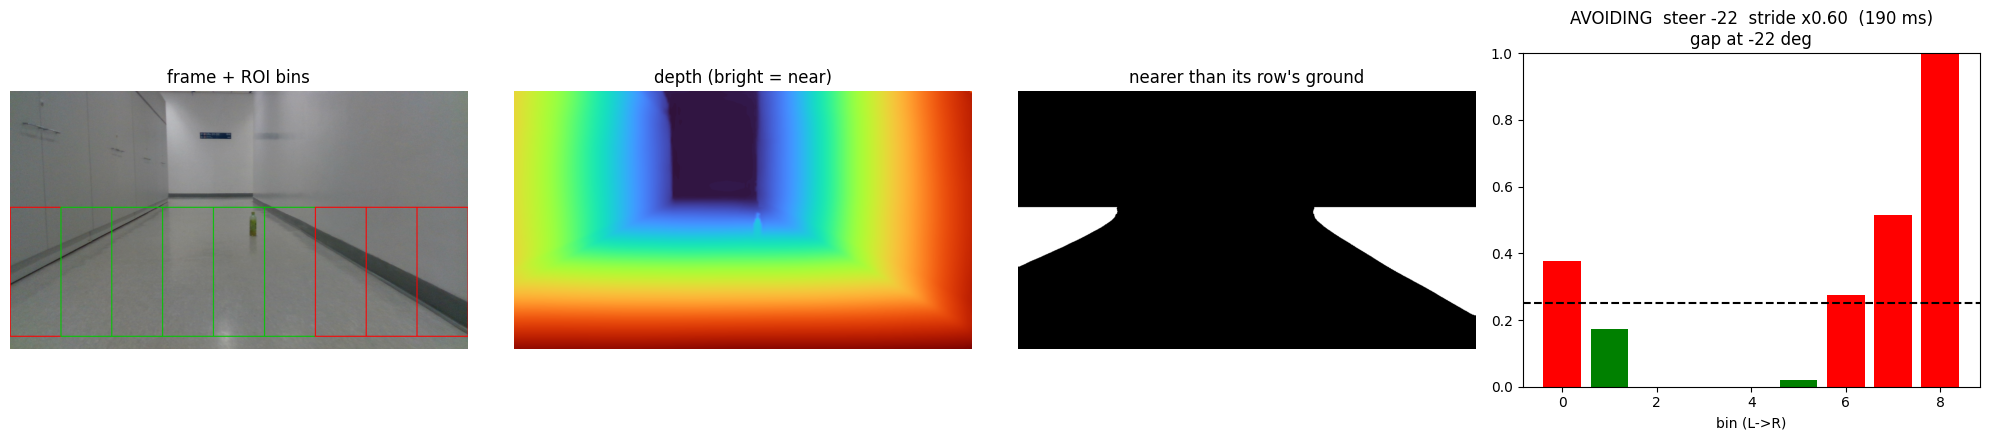

=== paving_box: low box on textured paving, hedge right


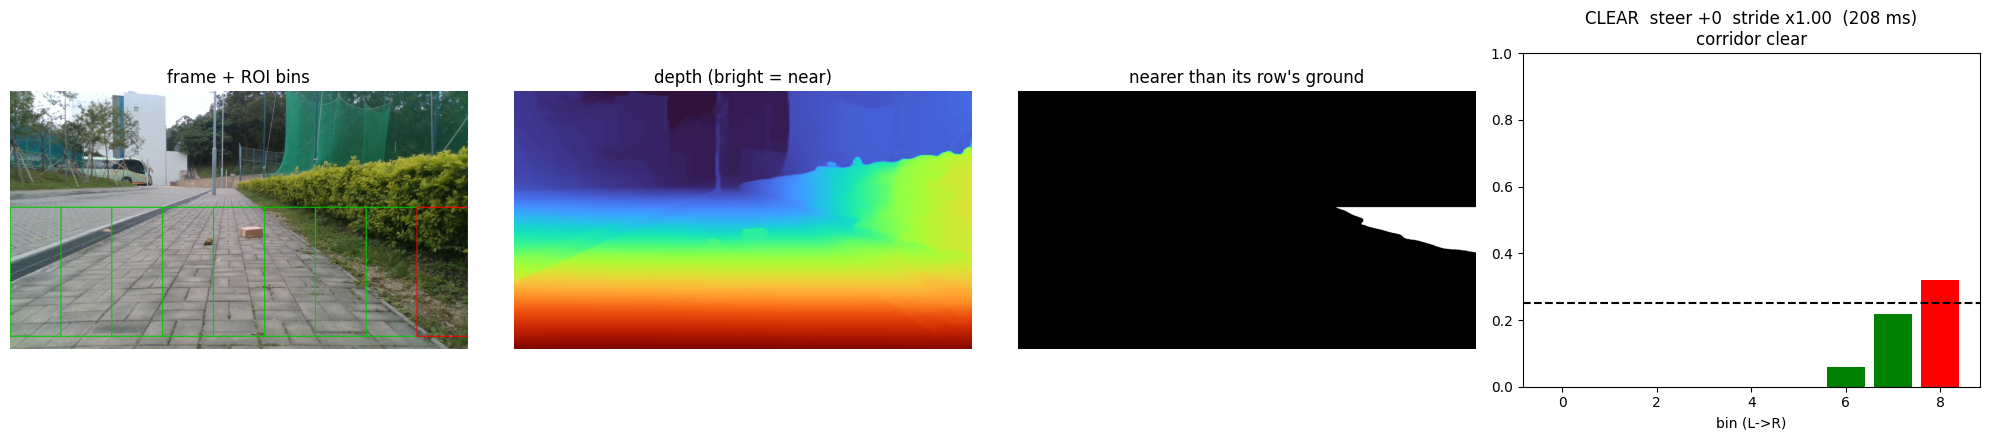

=== trail_narrow: earth bank close on the left


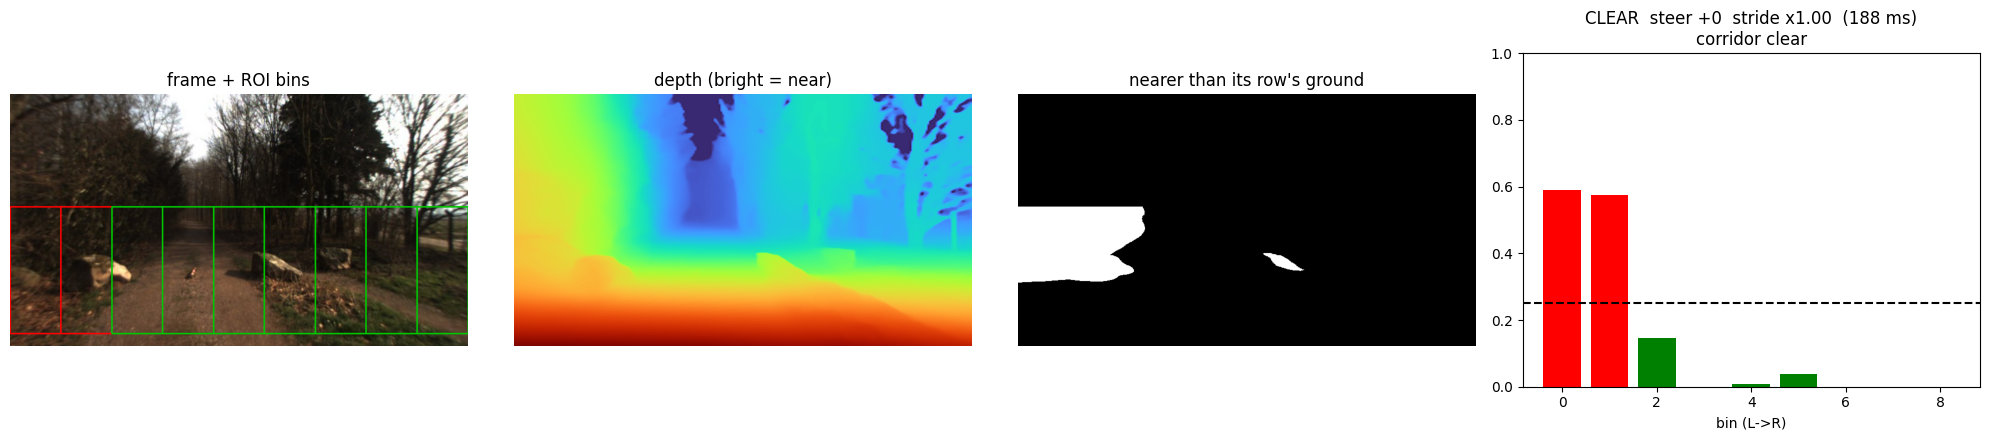

=== trail_pinch: gap pinches below body width; into the sun


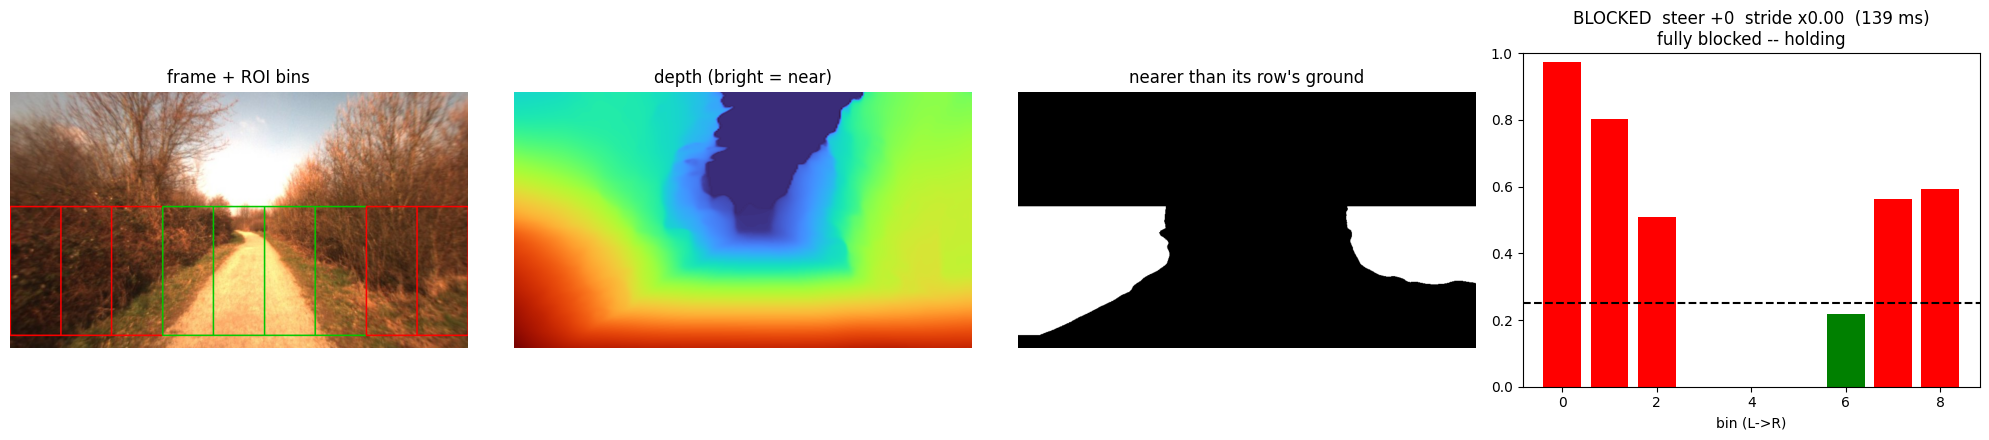

=== trail_fork: fork -- vegetation splits the path


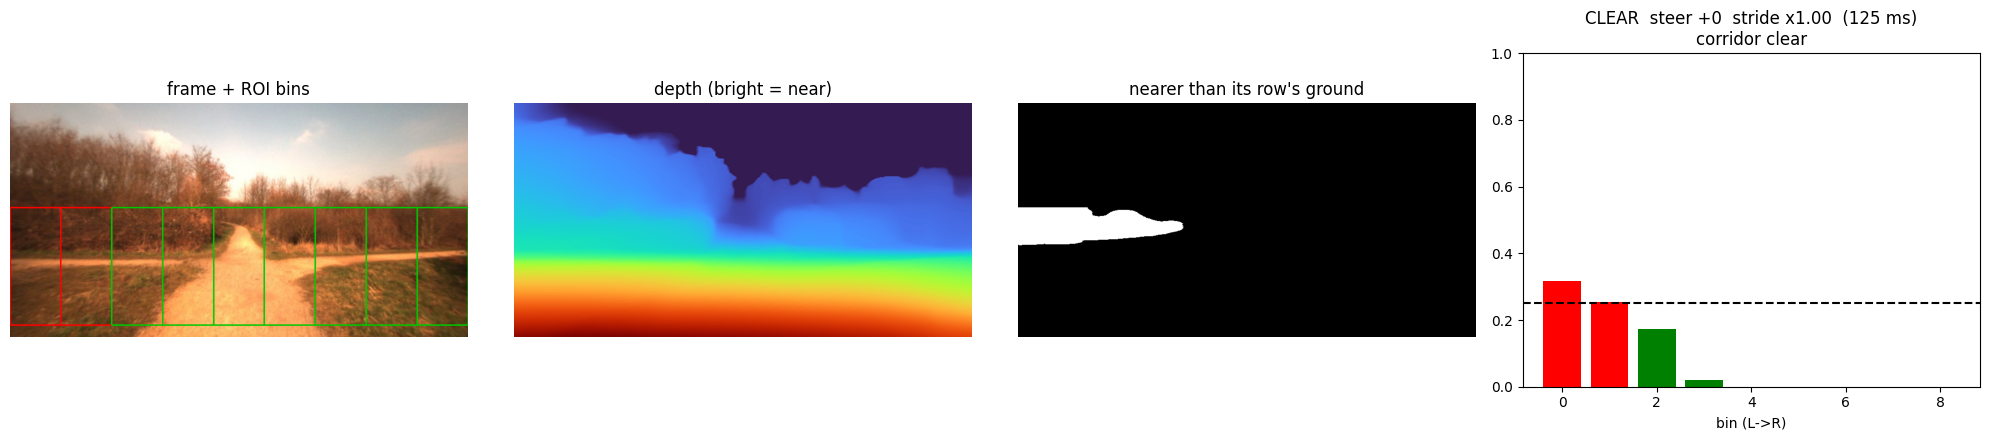

=== trail_twotrack: grass/mud texture must not trip


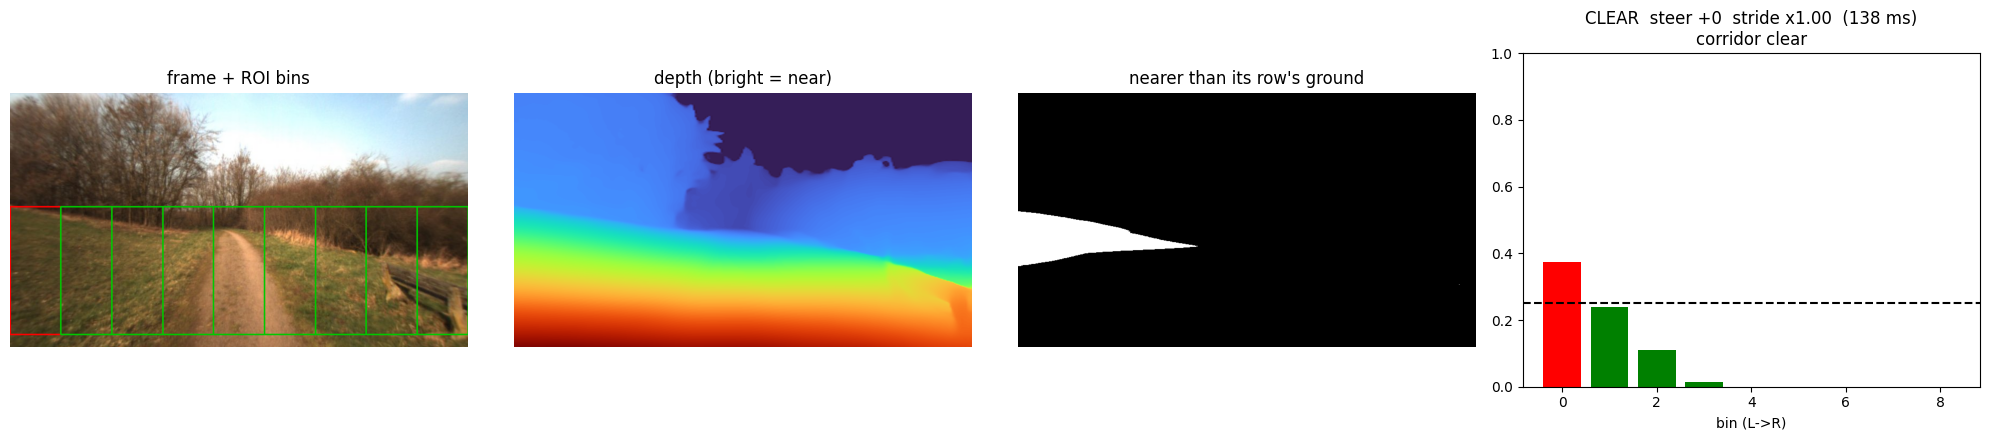

=== trail_dusk: flat light, dark bank fills the left


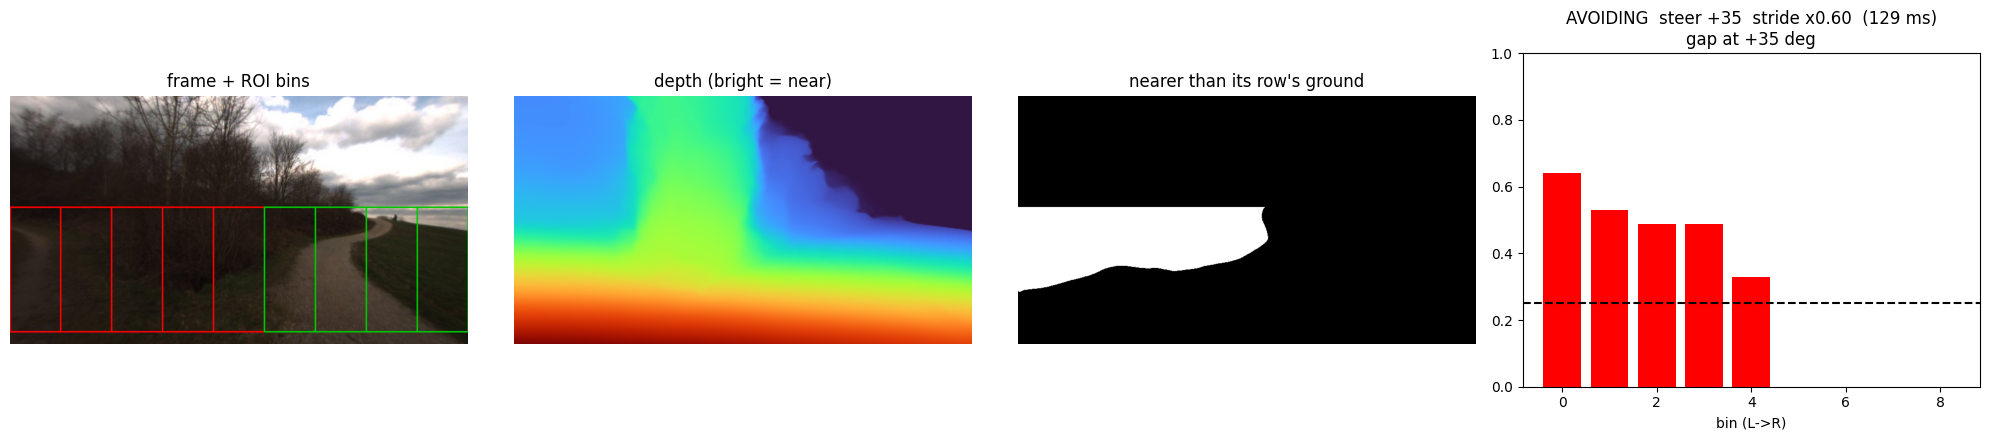

=== trail_open: distant conifers must not block


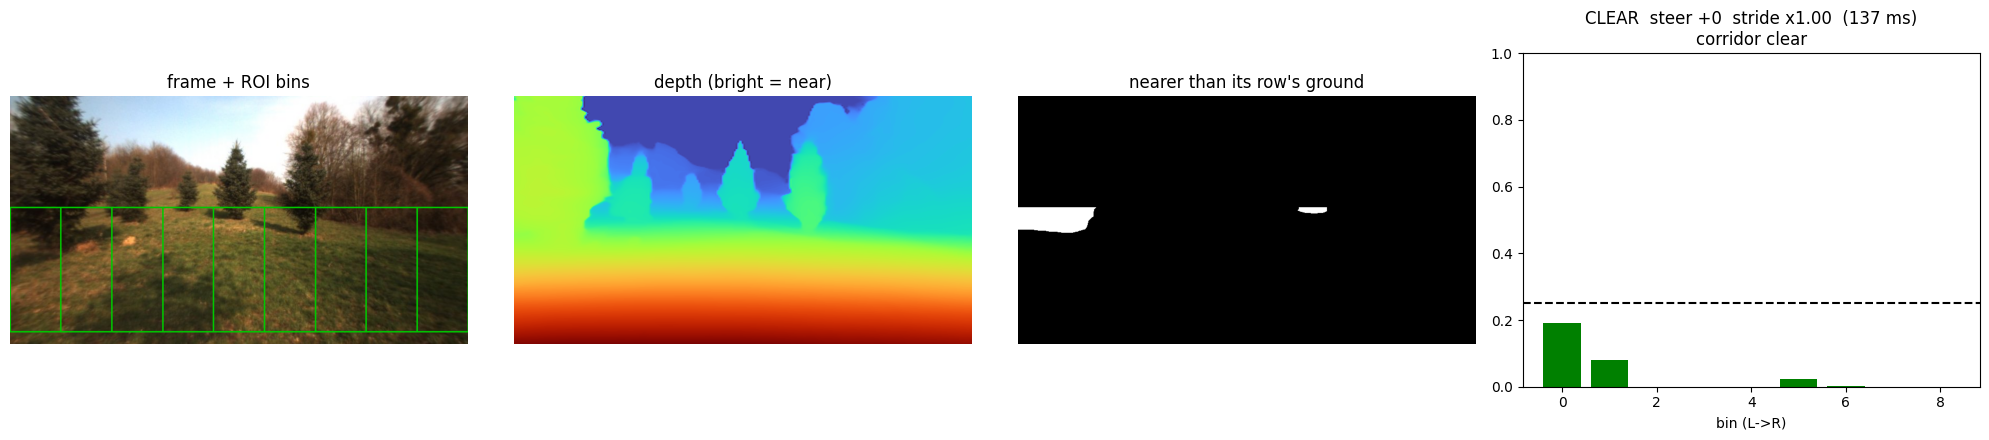

In [9]:
for name, (bgr, depth, cost, dec) in results.items():
    print(f"=== {name}: {TEST_IMAGES[name][1]}")
    show(bgr, depth, cost, dec)

### Reading the results

Two of these are worth understanding rather than "fixing".

**`trail_pinch` comes back BLOCKED, and that is correct.** It looks walkable,
but the clear gap measures 26.7°, and the robot is 72 cm across the
abductors:

| distance ahead | gap width | fits? |
|---|---|---|
| 1.0 m | 47 cm | no |
| 1.5 m | 71 cm | exactly borderline |
| 2.0 m | 95 cm | yes |

So the path is genuinely too tight in the near field and opens up further
out. Halting is the right call, and it is a good illustration of the
range-dependence limitation in `KNOWN_ISSUES.md` — the costmap has no depth
axis, so it cannot say "tight now, fine in a metre".

**`paving_box` misses the cardboard box.** A real limitation, not a tuning
artefact: the box is low, small in frame, and several metres out, so it moves
few enough pixels past `OBSTACLE_MARGIN` that its bin never reaches
`BLOCK_FRAC`. It would be picked up as the robot closed on it. Low obstacles
at distance are the weak spot of this approach, and the `ABORTED` foot-contact
recovery is the backstop.

Also worth noting: `INFLATE_BINS = 1` is doing real work here. Dropping it to
0 makes `corridor_bottle` report CLEAR with a wall down each side.

## Test 2 — webcam

`USBWebcam` below is a **copy** of `Code/Pi5/webcam.py`, on purpose, so this
notebook never imports the flight code.

In [ ]:
class USBWebcam:
    def __init__(self, device=CAM_DEVICE, width=640, height=480):
        self.cap = cv2.VideoCapture(device, cv2.CAP_V4L2)
        if not self.cap.isOpened():
            print(f"could not open {device}; falling back to index 0")
            self.cap = cv2.VideoCapture(0)
        self.cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
        print("camera open:", self.cap.isOpened())

    def read(self):
        ok, frame = self.cap.read()
        return frame if ok else None

    def release(self):
        self.cap.release()

In [ ]:
# single frame
cam = USBWebcam()
for _ in range(5):            # let auto-exposure settle
    cam.read(); time.sleep(0.1)
frame = cam.read()
cam.release()

if frame is None:
    print("no frame captured")
else:
    depth, cost, dec = analyze(frame)
    print(dec)
    show(frame, depth, cost, dec)

In [ ]:
# live loop, rendered inline (works over SSH / headless). ~40 frames then stops.
from IPython.display import clear_output

cam = USBWebcam()
try:
    for k in range(40):
        frame = cam.read()
        if frame is None:
            continue
        depth, cost, dec = analyze(frame)
        clear_output(wait=True)
        show(frame, depth, cost, dec)
        print(f"frame {k:3d}   {dec['action']:5s}  steer {dec['steer_deg']:+.0f}°   {dec['ms']:.0f} ms")
finally:
    cam.release()

In [ ]:
# live loop in an OpenCV window — only if you have a desktop on the Pi. Press q to quit.
cam = USBWebcam()
try:
    while True:
        frame = cam.read()
        if frame is None:
            break
        depth, cost, dec = analyze(frame)
        vis = frame.copy(); h, w = vis.shape[:2]
        y0, y1 = int(h*ROI_TOP), int(h*ROI_BOTTOM)
        for i in range(N_BINS):
            x0, x1 = int(i*w/N_BINS), int((i+1)*w/N_BINS)
            c = float(cost[i])
            cv2.rectangle(vis, (x0, y0), (x1, y1), (0, int(255*(1-c)), int(255*c)), 2)
        cv2.putText(vis, f"{dec['action']} {dec['steer_deg']:+.0f}deg  {dec['ms']:.0f}ms",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
        dvis = cv2.applyColorMap((depth*255).astype(np.uint8), cv2.COLORMAP_TURBO)
        cv2.imshow("apex obstacle test", np.hstack([vis, dvis]))
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cam.release()
    cv2.destroyAllWindows()

## Test 3 — FPS benchmark

Try `INPUT_SIZE` 266 vs 350 vs 518, and `USE_INT8` True vs False, re-running the
config + model cells between changes.

In [ ]:
cam = USBWebcam()
buf = []
for _ in range(20):
    f = cam.read()
    if f is not None:
        buf.append(f)
cam.release()

if buf:
    depth_model.infer(buf[0])                      # warm-up
    t0 = time.time()
    for f in buf:
        depth_model.infer(f)
    dt = (time.time() - t0) / len(buf)
    print(f"INPUT_SIZE={INPUT_SIZE}  int8={USE_INT8}   {dt*1000:.0f} ms/frame   {1/dt:.2f} FPS")
else:
    print("no frames — run on the Pi with the camera connected")

## Test 4 — synthetic sanity check

No model and no camera: depth maps built from the flat-ground equation, fed
through the real `costmap_from_depth` and `AvoidancePlanner`. This is the
regression test for the "ground reads as an obstacle" bug, and is also run
by `python3 vision_obstacle.py`.

In [ ]:
for name, depth, want in V._synthetic_scenes():
    cost = V.costmap_from_depth(depth)
    bars = "".join("#" if c >= V.BLOCK_FRAC else "." for c in cost)
    print(f"{'ok ' if want(cost) else 'BAD'} {name:22s} [{bars}]  "
          + " ".join(f"{c:.2f}" for c in cost))

print()
for name, depth, _ in V._synthetic_scenes():
    p = V.AvoidancePlanner()
    d = p.update(V.costmap_from_depth(depth), 0.0)
    print(f"  {name:22s} -> {d.state:9s} steer {d.steer_deg:+6.1f} "
          f"stride {d.stride_scale:.2f}")

## Tuning

All of these live in `Code/Pi5/vision_obstacle.py`. Edit there, restart the
kernel, re-run — the robot picks up the same values.

| knob | what it does |
|---|---|
| `INPUT_SIZE` | inference resolution, multiple of 14. Lower = faster, coarser |
| `ROI_TOP` / `ROI_BOTTOM` | which band is "the ground ahead". **Camera-mount dependent — set this first**, by eye against a real still |
| `OBSTACLE_MARGIN` | how much nearer than its row's ground a pixel must read. Raise if terrain texture trips it, lower if low obstacles slip through |
| `GROUND_REF_PCT` | percentile used as each row's ground reference. Below the median on purpose, so a wide object cannot hide itself |
| `FLAT_GRADIENT_MIN` | catches a wall filling a column, where there is no near/far contrast to find. Raising it halts more readily |
| `BLOCK_FRAC` | fraction of a bin flagged before it counts as blocked |
| `CORRIDOR_BINS`, `INFLATE_BINS`, `AVOID_MARGIN_DEG` | how much room the body needs, and how wide it swings |
| `CLEAR_HOLD_S` | how long to drive straight after the obstacle leaves view. **The parameter that decides clearing vs. grazing** |

**Order to tune in:** `ROI_*` first (look at the overlay), then
`OBSTACLE_MARGIN` against real obstacles at real distances, then the planner
geometry.

## Known limits

- Monocular depth is **relative, not metric** — no true distances, and the
  scale shifts frame to frame.
- **Drop-offs and holes read as *farther*, never nearer, so they are never
  flagged.** The FSR / `ABORTED` recovery path is the only backstop, and it
  fires on contact.
- Thin obstacles (wires, table legs) are unreliable at this resolution.
- The corridor is a fixed angle, but the angle a 72 cm body subtends depends
  on range — see `KNOWN_ISSUES.md`.